# NovaRetail+ — Behavioral Factors Associated with Annual Revenue

*Correlational (exploratory) analysis · TripleTen Data Analysis program, Sprint 8 project*


NovaRetail+ is a Latin American e-commerce platform with millions of users.

For the close of 2024, the **Growth and Retention** team aims to answer:

**Which customer behavior factors are most strongly associated with the annual revenue generated?**

> This project is a **correlational** (exploratory) analysis.  
> **Correlation ≠ causation.**


## Section 1 - Load and explore the dataset


In this section we validate:
- that the dataset loads correctly
- data types
- missing values / general ranges

Before correlating, we first understand the "terrain".


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy.stats as stats
warnings.filterwarnings("ignore")


### Load Dataset


In [2]:
import pandas as pd

# Raw dataset, committed in the repository root.
df = pd.read_csv('novaretail_comportamiento_clientes_2024.csv')

#### Dataset description

The dataset contains the following columns:

- `customer_id` — Unique customer identifier.
- `age` — Customer age.
- `income_level` — Estimated annual income of the customer.
- `monthly_visits` — Number of visits to the app or website during the month.
- `monthly_purchases` — Number of purchases made in the month.
- `targeted_ad_spend` — Advertising spend assigned to the user.
- `satisfaction` — Customer satisfaction rating on a scale of 1 to 5.
- `premium_member` — Indicates whether the customer has a premium subscription (1) or not (0).
- `churn` — Indicates whether the customer churned (1) or not (0).
- `device_type` — Type of device used by the customer (mobile, desktop, or tablet).
- `region` — Geographic region of the customer (north, south, west, or east).
- `annual_revenue` — Annual revenue generated by the customer for the company.

The main metric of analysis is `annual_revenue`, used to evaluate the economic impact of customers.


In [3]:
# First five rows
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Section 2 - Prepare the data and document assumptions


### Exploration and cleaning


In [4]:
# Rename columns to English
translation = {
    "id_cliente": "customer_id",
    "edad": "age",
    "nivel_ingreso": "income_level",
    "visitas_mes": "monthly_visits",
    "compras_mes": "monthly_purchases",
    "gasto_publicidad_dirigida": "targeted_ad_spend",
    "satisfaccion": "satisfaction",
    "miembro_premium": "premium_member",
    "abandono": "churn",
    "tipo_dispositivo": "device_type",
    "region": "region",
    "ingreso_anual": "annual_revenue"
}

df = df.rename(columns=translation)

In [5]:
# First exploration of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        15000 non-null  object 
 1   age                15000 non-null  float64
 2   income_level       15000 non-null  float64
 3   monthly_visits     15000 non-null  int64  
 4   monthly_purchases  15000 non-null  int64  
 5   targeted_ad_spend  15000 non-null  float64
 6   satisfaction       15000 non-null  float64
 7   premium_member     15000 non-null  int64  
 8   churn              15000 non-null  int64  
 9   device_type        15000 non-null  object 
 10  region             15000 non-null  object 
 11  annual_revenue     15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Initial data exploration
The dataset contains **15,000 records** and **12 columns**, with no missing values.

**Numerical variables**  
The following numerical columns are identified:
- `age`
- `income_level`
- `monthly_visits`
- `monthly_purchases`
- `targeted_ad_spend`
- `satisfaction`
- `premium_member` (could be converted to boolean or left as binary 0/1)
- `churn` (could be converted to boolean or left as binary 0/1)

**Binary variables**  
The following columns represent binary variables:
- `premium_member`
- `churn`

Both are coded as 0 and 1, so **no additional transformation is required for this project**.

**Categorical variables**  
The following categorical columns are identified:
- `customer_id`
- `device_type`
- `region`

These variables are correctly defined and do not require additional transformation.


#### Explore numerical variables


In [6]:
# Descriptive statistics
df[['age',
'income_level',
'monthly_visits',
'monthly_purchases',  
'targeted_ad_spend',
'satisfaction']].describe()

,age,income_level,monthly_visits,monthly_purchases,targeted_ad_spend,satisfaction
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000


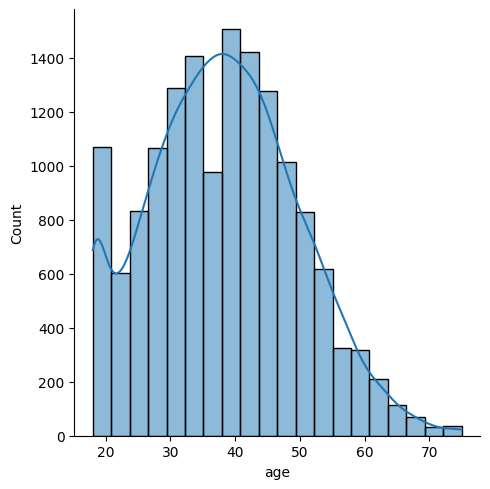

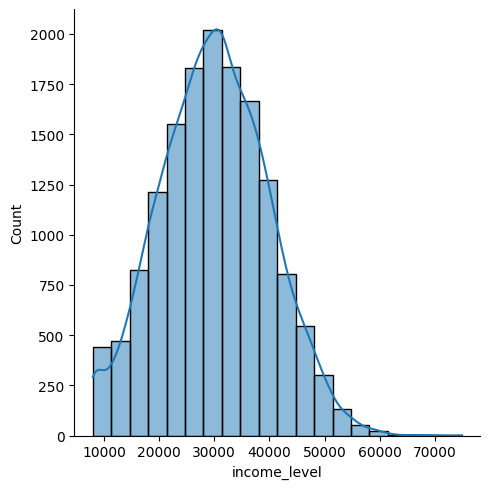

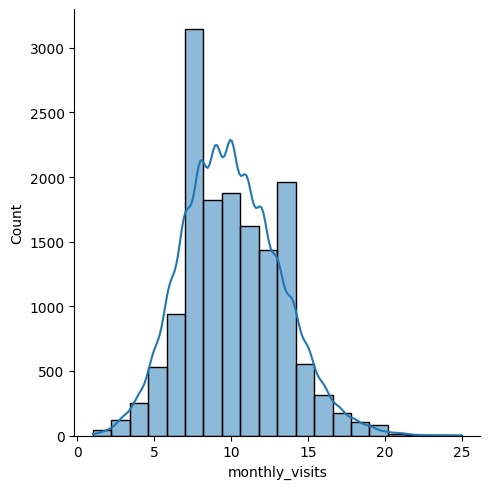

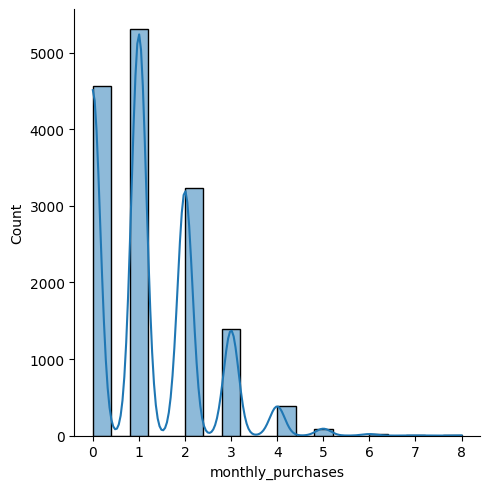

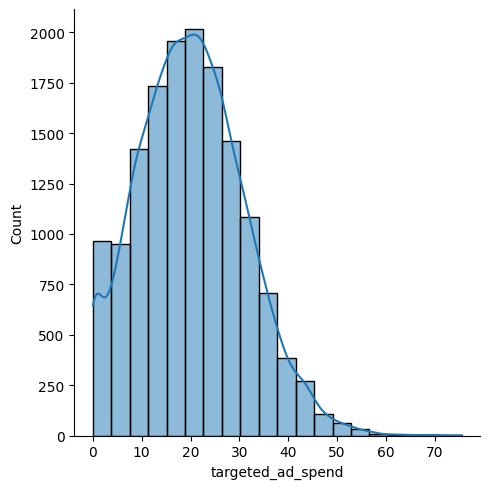

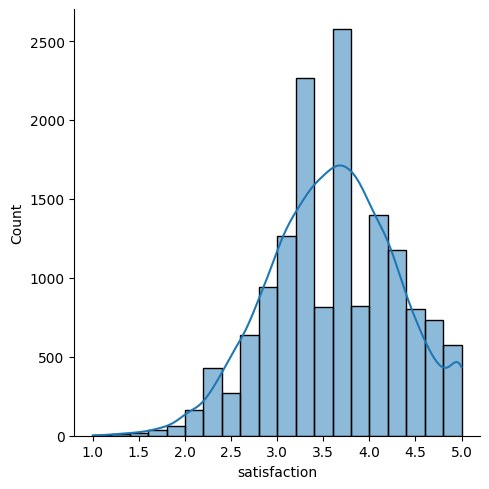

In [7]:
for col in ["age", "income_level", "monthly_visits", "monthly_purchases",
            "targeted_ad_spend", "satisfaction"]:
    sns.displot(df, x=col, kde=True, bins=20)

**Initial diagnosis of numerical variables:**

age — ✅ The distribution is centered around a typical adult age range, with no major anomalies suggesting a broad but reasonably balanced customer base.

income_level — ✅ Values appear concentrated in the middle-to-upper range with some dispersion, indicating that most customers belong to similar income segments while a smaller group may be at the extremes.

monthly_visits — ⚠️ The distribution has a light right skew: most customers have relatively low visit counts, while a smaller group has much higher values. This suggests a moderate right tail.

monthly_purchases — ⚠️ The distribution is highly uneven and concentrated at low values, with a few higher counts creating a visible tail. This suggests that most customers purchase infrequently, while a smaller group is more active.

targeted_ad_spend — ⚠️ Spending is highly right-skewed, with most customers receiving low ad investment and a small group receiving considerably larger budgets.

satisfaction — ✅ The variable is bounded and appears to cluster around moderate-to-high values, suggesting a generally positive customer experience.


#### Explore binary variables


In [8]:
# Verify that each binary column has only two values (0 and 1)
numerical_columns = ['premium_member', 'churn']
for col in numerical_columns:
    unique_values = df[col].unique()
    print(f"Number of unique values in '{col}': {df[col].nunique()}")
    print(f"Unique values in '{col}': {unique_values}")
    print(f"Value counts for '{col}':\n{df[col].value_counts(normalize=True)}\n")

Number of unique values in 'premium_member': 2
Unique values in 'premium_member': [0 1]
Value counts for 'premium_member':
0    0.860733
1    0.139267
Name: premium_member, dtype: float64

Number of unique values in 'churn': 2
Unique values in 'churn': [0 1]
Value counts for 'churn':
0    0.849267
1    0.150733
Name: churn, dtype: float64



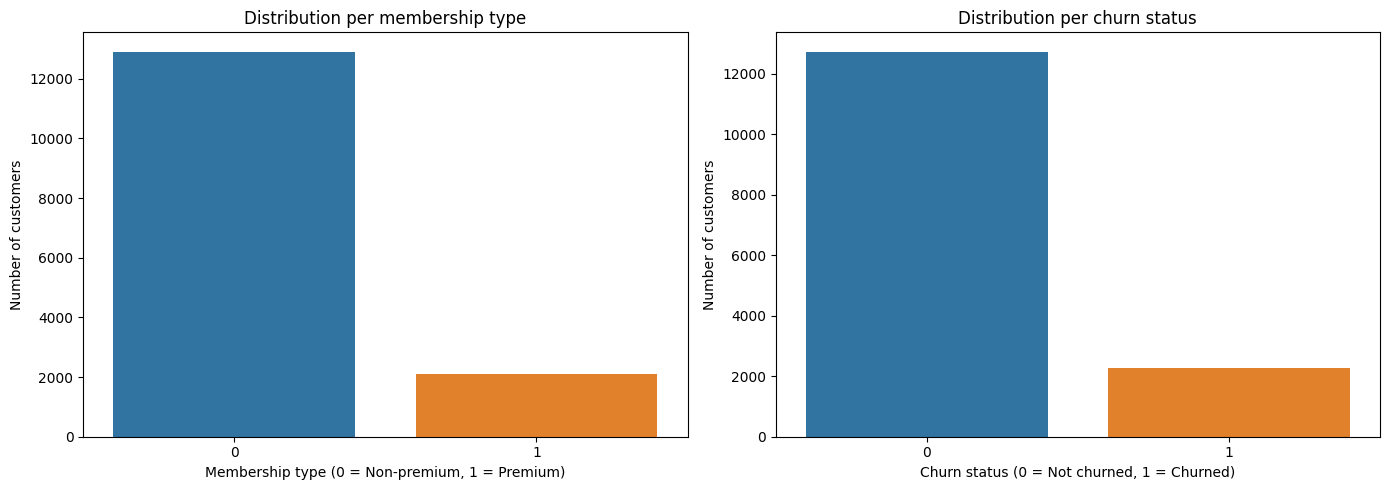

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df[df["premium_member"].notnull()],
    x="premium_member",
    ax=axes[0]
)
axes[0].set_title("Distribution per membership type")
axes[0].set_xlabel("Membership type (0 = Non-premium, 1 = Premium)")
axes[0].set_ylabel("Number of customers")

sns.countplot(
    data=df[df["churn"].notnull()],
    x="churn",
    ax=axes[1]
)
axes[1].set_title("Distribution per churn status")
axes[1].set_xlabel("Churn status (0 = Not churned, 1 = Churned)")
axes[1].set_ylabel("Number of customers")

plt.tight_layout()
plt.show()

**Diagnosis:** 
Initial diagnosis of binary variables

- `premium_member` — Has only two values: 0 and 1. Only about 13.9% are premium customers.
- `churn` — Has only two values: 0 and 1. Around 15.07% of customers have churned.


#### Explore categorical variables


In [10]:
# Check the number of unique values per categorical variable and how they are distributed
categorical = ['device_type', 'region']
for col in categorical:
    print(f"Number of unique values in '{col}': {df[col].nunique()}")
    print(f"Unique values in '{col}': {df[col].unique()}")
    print(f"Value counts for '{col}':\n{df[col].value_counts(normalize=True)}\n")

Number of unique values in 'device_type': 3
Unique values in 'device_type': ['móvil' 'tablet' 'escritorio']
Value counts for 'device_type':
móvil         0.654533
escritorio    0.248000
tablet        0.097467
Name: device_type, dtype: float64

Number of unique values in 'region': 4
Unique values in 'region': ['norte' 'sur' 'este' 'oeste']
Value counts for 'region':
norte    0.2930
oeste    0.2540
sur      0.2484
este     0.2046
Name: region, dtype: float64



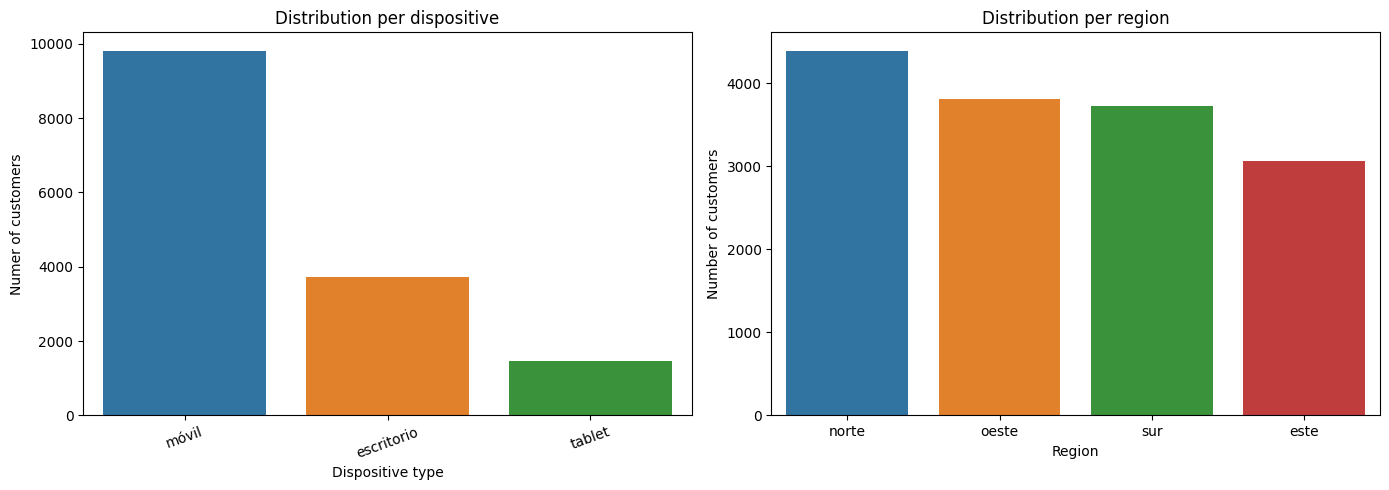

In [11]:
# Customer distribution by device type and region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df,
    x="device_type",
    order=df["device_type"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("Distribution per dispositive")
axes[0].set_xlabel("Dispositive type")
axes[0].set_ylabel("Numer of customers")
axes[0].tick_params(axis="x", rotation=20)

sns.countplot(
    data=df,
    x="region",
    order=df["region"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Distribution per region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Number of customers")

plt.tight_layout()
plt.show()

Initial diagnosis of categorical variables

device_type: mobile is the dominant category, followed by desktop and tablet.
region: the distribution is fairly spread across regions, with no extreme imbalance.


### Assumptions

- The analysis is performed using the **entire available dataset**.
- The data do not contain errors and are correctly typed.
- Different coefficients are used according to variable type:
  - **Pearson** assumes linear relationships between numerical variables.
  - **Spearman** evaluates monotonic relationships and does not require normality.
  - **Point-biserial** is used for numerical–binary relationships.
  - **Cramér's V** is used for associations between categorical variables.

**Central assumption:**  
This analysis identifies relationships between variables or segments, but does not test causality.


## Section 3 - Visualization of relationships

We observe how the numerical variables relate to one another.


### Heatmap


Text(0.5, 1.0, 'Heatmap of Correlations (First impressions calculated with Pearson Correlation Coefficient)')

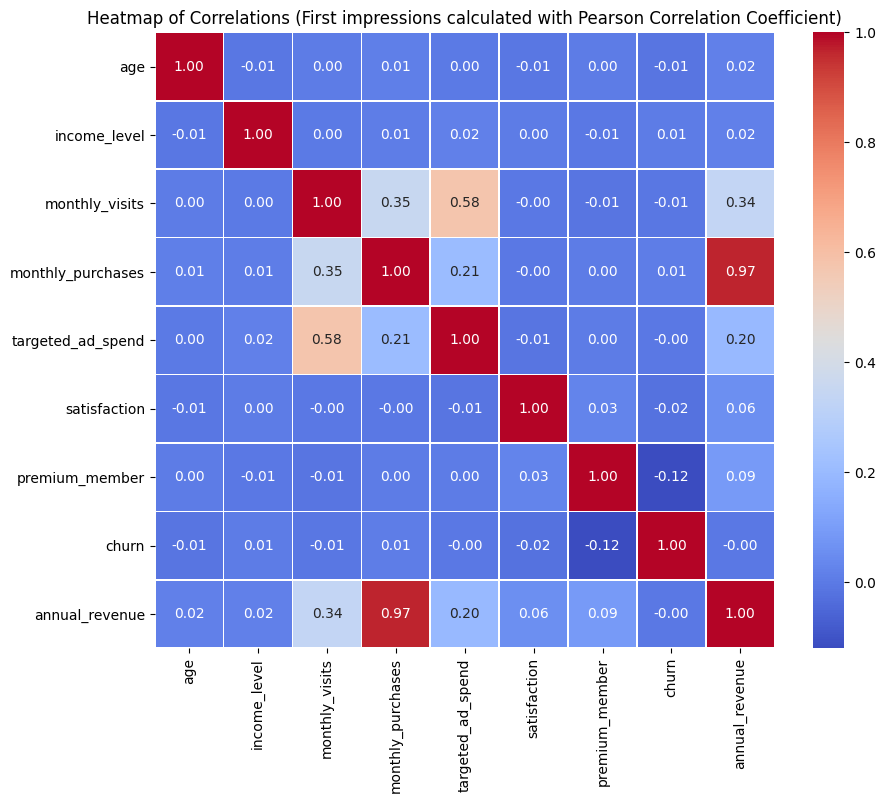

In [12]:
# Visualize the correlation matrix to identify relationships
numerical_columns = ['age', 'income_level', 'monthly_visits', 'monthly_purchases',
                     'targeted_ad_spend', 'satisfaction', 'premium_member', 'churn', 'annual_revenue']
heatmap = df[numerical_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Correlations (First impressions calculated with Pearson Correlation Coefficient)")

Initial diagnosis:

**General observations (Heatmap)**  
The strongest patterns are seen among variables related to customer activity and spending, especially `monthly_visits`, `monthly_purchases`, and `targeted_ad_spend`.  
- These variables appear to move together more closely than the rest of the numeric features.  
- Weaker correlations near zero suggest little to no linear association between some variables.

**Observations regarding `annual_revenue`**  
- `annual_revenue` shows a more relevant relationship with behavioral and spending variables: `monthly_visits` (moderate), `monthly_purchases` (extremely high), and `targeted_ad_spend` (moderate), suggesting that these metrics may be associated with customer economic performance.


### General scatterplot


It is not necessary to include a general scatterplot because the analysis can focus on the key variables of interest. A general scatterplot would be less informative, visually saturated, and less aligned with the business question.


### Scatterplot for key pairs


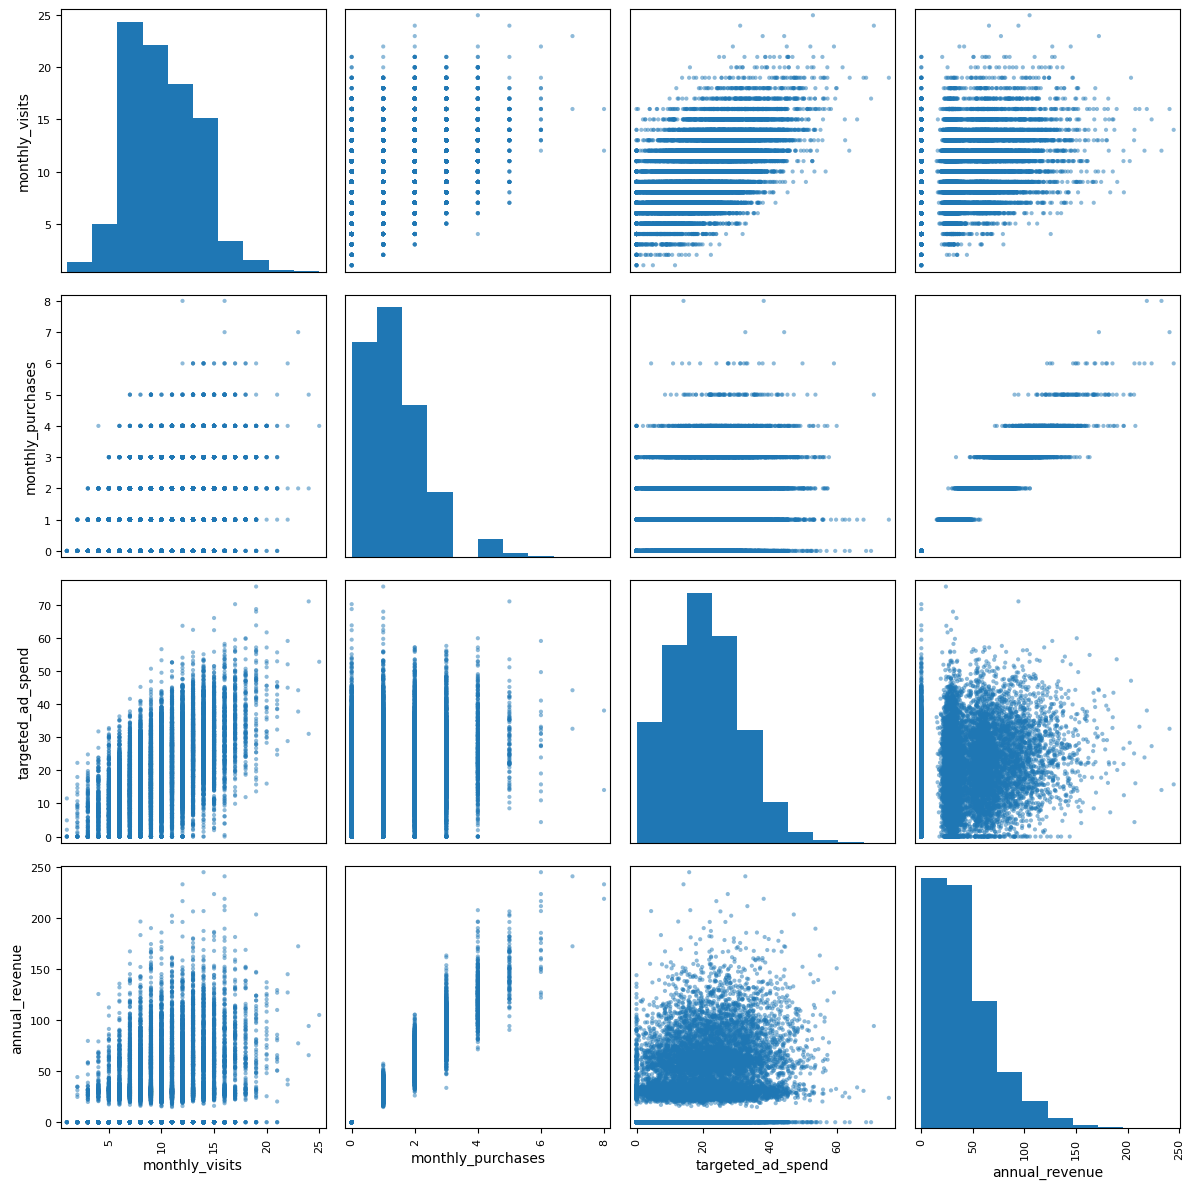

In [13]:
# Select key numeric columns for scatter plots based on correlation analysis
key_numeric_columns = ['monthly_visits', 'monthly_purchases', 'targeted_ad_spend', 'annual_revenue']

scatter_matrix = pd.plotting.scatter_matrix(
    df[key_numeric_columns],
    figsize=(12, 12),
    diagonal="hist",
    alpha=0.5
)

plt.tight_layout()
plt.show()

**First general impressions (scatterplot)**
**monthly_visits vs monthly_purchases**
- The relationship appears to be positive, although the cloud of points is somewhat dispersed.
- Outliers are present, especially in monthly_purchases, which shows a clear right-skewed distribution.
- This suggests that customers with more visits tend to make more purchases, but the relationship is not perfectly linear.

**monthly_visits vs targeted_ad_spend**
- The relationship is positive with moderate dispersion.
- Outliers are present, especially in targeted_ad_spend, which also has a right-skewed shape.
- This may suggest that more active customer behavior may be linked with higher marketing investment, although the pattern is not uniform.

**monthly_purchases vs targeted_ad_spend**
- The relationship is positive, but noisy due to high dispersion and extreme values.
- Outliers in both variables make the association less clear and reduce the strength of the visual pattern.
- This analysis may suggest that purchase activity and ad spending are related, but not in a strictly consistent way.

**'monthly_visits' interpretation (scatterplot)**

**monthly_visits vs annual revenue**
- The association appears positive, with noticeable spread across the data.
- Outliers are present, especially in annual_revenue, which is right-skewed.
- This preliminary analysis could suggest that customers who visit more often tend to generate higher annual revenue, although other factors likely influence the final outcome.

**monthly_purchases vs annual_revenue**
- This pair shows the clearest positive relationship among the variables explored.
- The points tend to rise together, although there is still some dispersion and a small number of very high-value outliers in both variables.
- This pattern may suggest that higher purchase frequency is strongly associated with higher annual revenue, which is consistent with business logic. However, further analysis should be done to rule out redundancy or collinearity between both variables.


## Section 4 - Correlation coefficients and numerical evidence

In this section, coefficients are reported to support the patterns observed visually, using the method appropriate for each variable type.


### Pearson / Spearman


In [14]:
# Since all key numeric columns have outliers, the best method to calculate correlation is the Spearman Correlation Coefficient, which is more robust to outliers. Let's calculate the Spearman correlation matrix and visualize it with a heatmap.
spearman_corr = df[key_numeric_columns].corr(method='spearman')


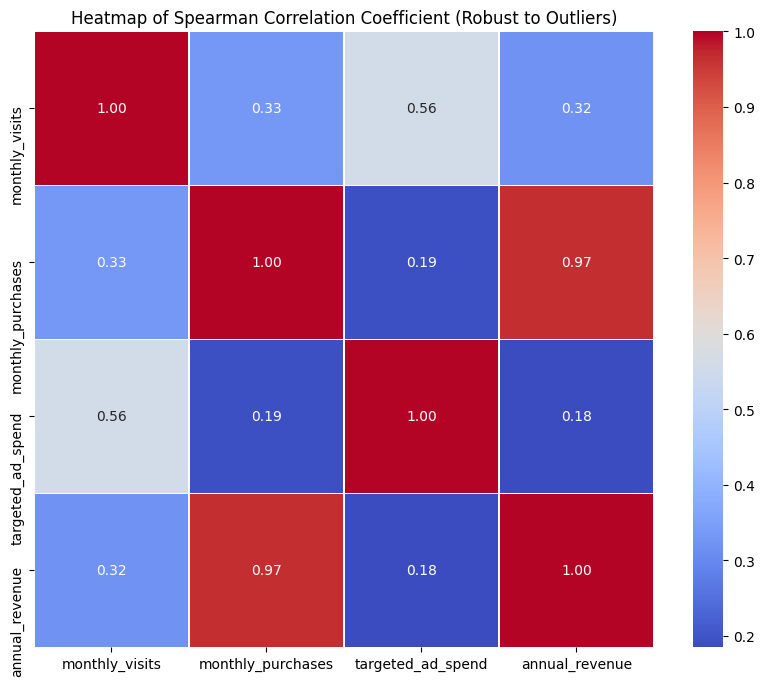

In [15]:
# Heatmap of Spearman Correlation Coefficient
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap of Spearman Correlation Coefficient (Robust to Outliers)")
plt.show()


A Spearman correlation heatmap is a rank-based version of the correlation matrix. Unlike Pearson, it focuses on whether variables increase or decrease together in order, not necessarily in a perfectly linear way. This makes it especially useful when the data are skewed or contain outliers, which is very common in this dataset.

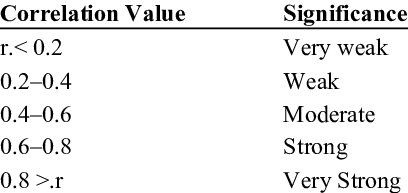

**General impressions:**

**monthly_visits vs monthly_purchases _(r = 0.33)_**

- Weak positive relationship.
- It further suggests that as customers visit more often, they tend to purchase more often (note: underlying causes may differ since correlation is not causation).
- Compared with the earlier analysis (Pearson), this relationship probably remains similar, but Spearman may be a bit more stable because it is less affected by the right-skewed extreme values.

**monthly_visits vs targeted_ad_spend _(r = 0.56)_**

- Moderate positive relationship.
- Customers with more visits tend to receive or generate more advertising spend, but the pattern is not as tight as with purchases.
- Compared with the previous analysis, it may appear slightly weaker than Pearson if the relationship was being driven by a few high-spend outliers.

**monthly_purchases vs targeted_ad_spend _(r = 0.19)_**

- Weak positive relationship.
- More purchasing activity appears to be associated with higher ad investment, but the link is not as direct as between visits and purchases.
- Compared with the earlier analysis, Spearman may reduce the apparent effect of extreme values and provide a more conservative estimate.

**Key impressions from the focus variable:**

**monthly_visits vs annual_revenue _(r = 0.32)_**

- Weak positive relationship.
- More active customers appear to contribute more revenue, though the association is not perfectly consistent.
- In Spearman, the relationship may be clearer than Pearson if the revenue pattern is monotonic but not strictly linear.

**monthly_purchases vs annual_revenue _(r = 0.97)_**

- Very strong positive monotonic relationship.
- This pair remains the strongest in the Spearman correlation matrix, consistent with the earlier Pearson-based interpretation.
- The data indicate that customers with higher monthly purchase counts tend to generate higher annual revenue.
- However, this is still a correlation (association), not evidence of causality.
- Worth noting: an audit of how these variables are constructed may be useful to rule out redundancy.


### 4.2 Pearson vs Spearman comparison
To explicitly evaluate the impact of outliers and potential non-linear relationships, this section compares the Pearson correlation coefficients (introduced during the initial exploratory phase in Section 3) directly against Spearman's rank correlations for the exact same pairs of variables.


In [16]:
# import the combinations library to construct every unique pair of 2 elements in a list
from itertools import combinations

cols = ['monthly_visits', 'monthly_purchases', 'targeted_ad_spend', 'annual_revenue']

# 1. Compute correlation matrices
pearson_mat = df[cols].corr(method='pearson')
spearman_mat = df[cols].corr(method='spearman')

# 2. Extract pairs into a clean comparison list
data = []

#3. Take the list cols and give every possible unique combination of 2 items (all column pairs possible)
for var1, var2 in combinations(cols, 2):
    #3.1 Then calculate pearson and spearman for each combination
    r_p = pearson_mat.loc[var1, var2]
    r_s = spearman_mat.loc[var1, var2]
    #3.2 save and prepare results as a dictionary inside the list
    data.append({
        'Variable 1': var1,
        'Variable 2': var2,
        'Pearson (r)': round(r_p, 4),
        'Spearman (rho)': round(r_s, 4),
        'Difference': round(r_s - r_p, 4)
    })

# 3.3 Transform list/dictionary  to a comparison DataFrame
df_comparison = pd.DataFrame(data)
df_comparison



,Variable 1,Variable 2,Pearson (r),Spearman (rho),Difference
0,monthly_visits,monthly_purchases,0.3538,0.3329,-0.0209
1,monthly_visits,targeted_ad_spend,0.5789,0.5593,-0.0197
2,monthly_visits,annual_revenue,0.3371,0.3210,-0.0162
3,monthly_purchases,targeted_ad_spend,0.2075,0.1925,-0.0150
4,monthly_purchases,annual_revenue,0.9671,0.9675,0.0003
5,targeted_ad_spend,annual_revenue,0.1975,0.1850,-0.0125


### Point-biserial


In [17]:
# import pointbiserialr
from scipy.stats import pointbiserialr

# Select relevant columns for point biserial correlation analysis
key_numeric_columns = ['monthly_visits', 'monthly_purchases', 'targeted_ad_spend', 'annual_revenue']
key_binary_columns = ['premium_member', 'churn']

#Calculate point biserial correlation for each pair of numeric and binary columns
point_biserial_results = {}
for binary_col in key_binary_columns:
    for numeric_col in key_numeric_columns:
        corr, p_value = pointbiserialr(df[numeric_col], df[binary_col])
        point_biserial_results[(numeric_col, binary_col)] = (corr, p_value)

In [18]:
# Show the results
for (numeric_col, binary_col), (corr, p_value) in point_biserial_results.items():
    print(f"Point Biserial Correlation between '{numeric_col}' and '{binary_col}': {corr:.4f}, p-value: {p_value:.4e}")

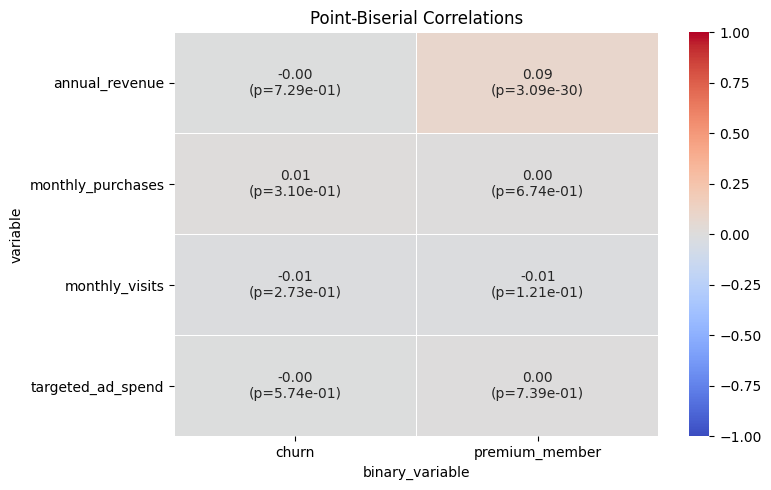

,variable,binary_variable,correlation,p_value,annotation
0,monthly_visits,premium_member,-0.012657,1.211330e-01,-0.01\n(p=1.21e-01)
1,monthly_purchases,premium_member,0.003431,6.743982e-01,0.00\n(p=6.74e-01)
2,targeted_ad_spend,premium_member,0.002721,7.389843e-01,0.00\n(p=7.39e-01)
3,annual_revenue,premium_member,0.093099,3.094308e-30,0.09\n(p=3.09e-30)
4,monthly_visits,churn,-0.008943,2.734362e-01,-0.01\n(p=2.73e-01)
5,monthly_purchases,churn,0.008291,3.099365e-01,0.01\n(p=3.10e-01)
6,targeted_ad_spend,churn,-0.004586,5.743868e-01,-0.00\n(p=5.74e-01)
7,annual_revenue,churn,-0.002824,7.294692e-01,-0.00\n(p=7.29e-01)


In [19]:
# Point-biserial correlations with p-values
#Create a DataFrame to store the results for better visualization
results = pd.DataFrame(
    [
        [num, binary, corr, p_value]
        for (num, binary), (corr, p_value) in point_biserial_results.items()
    ],
    columns=["variable", "binary_variable", "correlation", "p_value"]
)
# Add a new column for annotations to display correlation and p-value in the heatmap
results["annotation"] = results.apply(
    lambda row: f"{row['correlation']:.2f}\n(p={row['p_value']:.2e})",
    axis=1
)

# Create a heatmap to visualize the point-biserial correlations
heatmap_data = results.pivot(
    index="variable",
    columns="binary_variable",
    values="correlation"
)

# Add annotations to the heatmap for better interpretation
annotations = results.pivot(
    index="variable",
    columns="binary_variable",
    values="annotation"
)

# Specify the size of the heatmap and plot it with annotations
plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=annotations,
    fmt="",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

# Add a title and adjust layout for better visualization
plt.title("Point-Biserial Correlations")
plt.tight_layout()
plt.show()

results

1. At first, the most relevant point-biserial relationship observed seems to be between annual_revenue and premium_member (r = 0.09, p = 3.09e-30). The association is highly statistically significant (p ≈ 3e-30, driven by the n = 15,000 sample size), yet the magnitude of the correlation remains extremely weak — a clear case where statistical significance and practical relevance diverge.
2. In business terms: premium membership shows a statistically detectable but weak association with annual revenue, suggesting that premium status alone is not a sufficient driver of revenue and should not be treated as a standalone growth lever without considering additional behavioral and commercial variables.
3. The remaining point-biserial associations are null, indicating that premium status and churn alone do not strongly explain variation in customer behavior or annual revenue. This suggests that revenue is driven more by broader behavioral patterns than by binary status alone.


### Cramér's V


In [20]:
# Relevant columns for Cramér's V calculation
categorical_columns = ['device_type', 'region']


# Creating a contingency table for two categorical variables
table = pd.crosstab(df[categorical_columns[0]], df[categorical_columns[1]])

# Calculate the Chi-squared statistic and p-value
chi2, p, dof, expected = stats.chi2_contingency(table)

# Calculate Cramér's V (Normalization of the Chi-squared statistic)
n = table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
print(f"Cramér's V between '{categorical_columns[0]}' and '{categorical_columns[1]}': {cramers_v:.4f}, p-value: {p:.4e}")


Cramér's V between 'device_type' and 'region': 0.0124, p-value: 5.9648e-01


1. The Cramér’s V association between device_type and region is very weak and statistically insignificant, suggesting little to no relationship between customer region and the device used to access the platform.
2. From a business perspective, this indicates that customer region does not appear to determine the type of device used to interact with the platform.


## Section 5 - Interpretation of results for the business

Each finding should include:
1) Visual evidence (if applicable)
2) Numerical evidence  
3) Interpretation (non-causal)  
4) What we cannot claim  
5) Business implication

---


### Finding 1 — Purchase frequency shows the strongest observed association with annual revenue

**Visual evidence:**

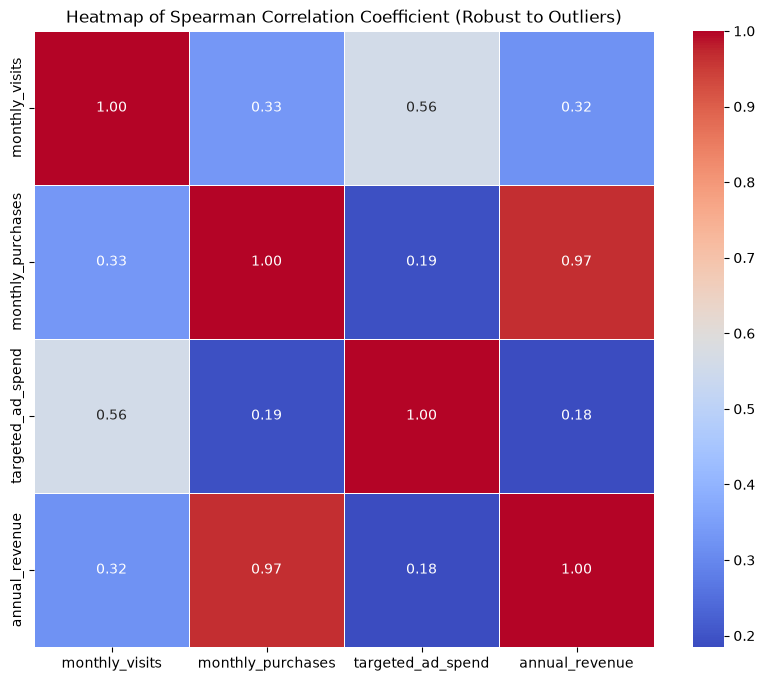

**Quantitative evidence:**

- In the Spearman correlation heatmap matrix, monthly_purchases and annual_revenue show the strongest association observed in the dataset _(r = 0.97)_.

**Interpretation:**

- This is the strongest association identified in the analysis and is consistent with the idea that higher purchase frequency is related to higher annual revenue.
- However, this relationship should be interpreted cautiously because it may reflect overlap in how these variables are constructed or measured, and a high correlation alone does not establish causality.

**Business implication:**

- Purchase frequency appears to be the most relevant behavioral signal in the dataset, but further validation is needed before treating it as a definitive causal driver.


### Finding 2 — Visit frequency and ad spend might be secondary drivers of annual revenue
**Visual evidence:**
- The scatterplots below for **monthly_visits vs annual_revenue** and **targeted_ad_spend vs annual_revenue** show a positive but dispersed pattern, suggesting that higher values are associated with higher revenue, but without a tight or perfectly linear relationship.


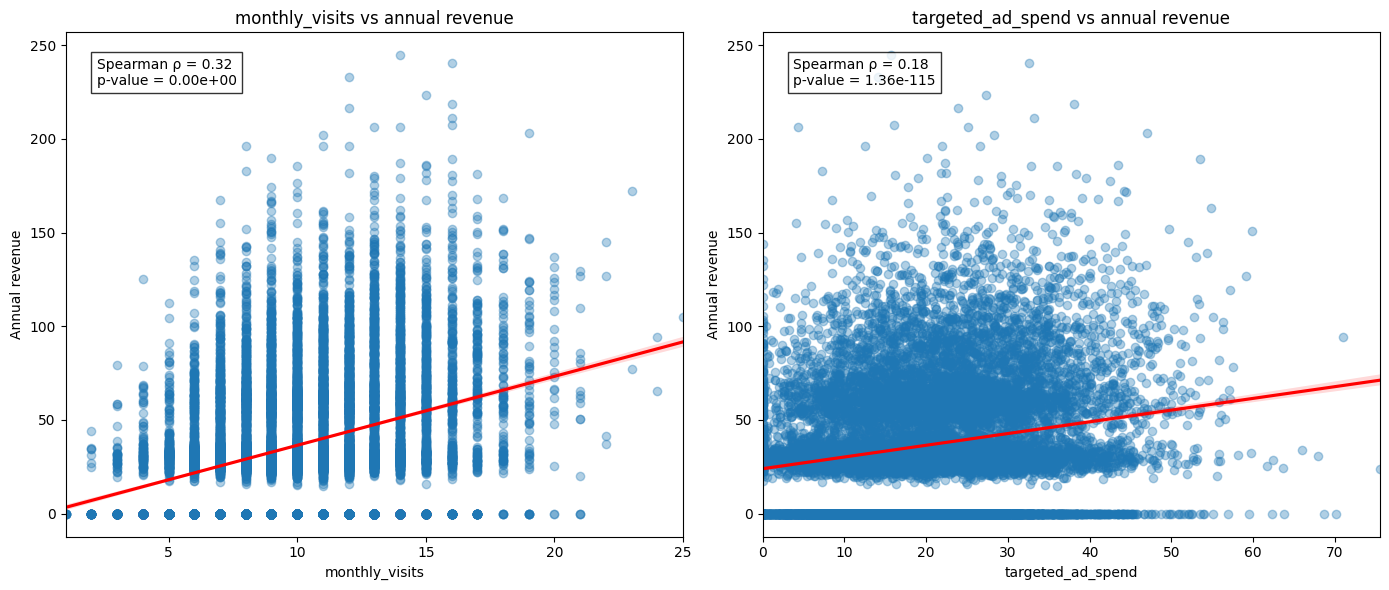

In [21]:
# Scatter plots with regression line + Spearman coefficient: monthly_visits and targeted_ad_spend vs annual_revenue
secondary_columns = ['monthly_visits', 'targeted_ad_spend']

# Create a scatter plot with regression line for the selected columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, column in zip(axes, secondary_columns):
    sns.regplot(
        data=df,
        x=column,
        y="annual_revenue",
        scatter_kws={"alpha": 0.35},
        line_kws={"color": "red"},
        ax=ax
    )

    rho, p_value = stats.spearmanr(df[column], df["annual_revenue"])

    ax.set_title(f"{column} vs annual revenue")
    ax.set_xlabel(column)
    ax.set_ylabel("Annual revenue")
    ax.text(
        0.05, 0.95,
        f"Spearman ρ = {rho:.2f}\np-value = {p_value:.2e}",
        transform=ax.transAxes,
        va="top",
        bbox=dict(facecolor="white", alpha=0.8)
    )

plt.tight_layout()
plt.show()


        

**Quantitative evidence:**
   1. Spearman correlation is _r = 0.32_ for **monthly_visits vs annual_revenue**  
   2. Spearman correlation is _r = 0.18_ for **targeted_ad_spend vs annual_revenue**

These values suggest weaker positive associations than the relationship observed for purchase frequency.

**Interpretation:**
- Customer engagement and marketing intensity appear to be related to revenue, but they are weaker signals than purchase behavior. More frequent visits may indicate higher customer activity, while advertising spend may be associated with higher revenue, although the relationship is weak and less consistent.

**Worth noting:** 

1. The current analysis does not establish that higher ad spend or more visits cause higher revenue.
2. It cannot be concluded that increasing visits or spending will automatically improve revenue.
3. The observed relationships are associative only and do not imply causality.

**Business implications:**

NovaRetail+ should treat customer engagement and marketing intensity as complementary indicators rather than primary drivers of revenue. A stronger business focus should remain on converting visits into purchases and improving retention, while evaluating ad efficiency through conversion-based performance metrics rather than spend alone.


### Finding 3 — Premium membership shows a statistically significant but very weak association with annual revenue

**Visual evidence:**

- The heatmap suggests that **annual_revenue vs premium membership** do not show a strong association, which is consistent with the weak effect size observed in the quantitative analysis.

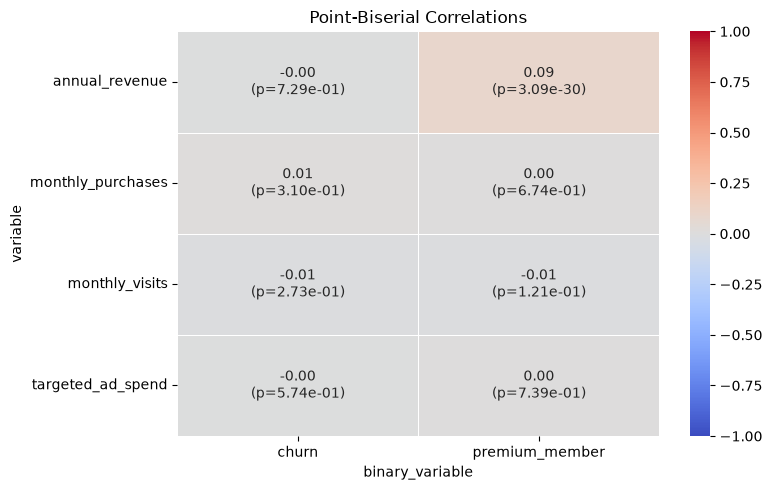

**Quantitative evidence (point-biserial analysis):**

- Point-biserial association: r = 0.09
- p-value = 3.09e-30

This indicates a highly significant but practically negligible association: with n = 15,000, even a trivial effect reaches significance, so effect size — not the p-value — is the decision-relevant quantity here.

**Interpretation:**

- Premium members tend to generate slightly higher annual revenue than non-premium members, but the relationship is extremely weak.
- This result suggests that premium status may be related to higher value, yet it is not a strong standalone explanatory factor for annual revenue in this dataset.

**Worth noting:**
- This does not prove that premium membership causes higher revenue.
- It does not mean premium membership is the main explanation for customer value.
- The effect size is too small to justify treating premium status as a primary revenue lever.

**Business implications:**
NovaRetail+ should view premium membership as a supporting factor rather than a main driver of revenue. Premium offers may still be relevant for retention and customer value, but they should be evaluated together with engagement, purchase frequency, and conversion behavior rather than on membership alone.


## Section 6 - Limitations and next steps


### **Limitations**
- Correlation does not imply causation: the findings identify associations, but they do not allow us to conclude that one variable causes another.
- The analysis is exploratory and cross-sectional: it does not establish the temporal direction of the relationships or whether one behavior precedes or follows another.
- There is a risk of redundancy among variables: for example, the relationship between monthly_purchases and annual_revenue may reflect metrics that measure similar aspects of customer value.
- Effect size matters: although some associations are statistically significant, such as premium_member vs annual_revenue, their magnitude is weak and may not be sufficient for high-impact strategic decisions.
- The categorical information available is limited: only device_type and region were analyzed, so other relevant customer segmentations were not explored.

### **Next steps**

Test additional segmentation
- Segment customers by premium_member, churn, and activity level to detect differences in behavior.
- Compare the performance of active versus inactive customers in terms of revenue and retention.
- Evaluate whether the impact of targeted_ad_spend changes by customer type or region.

[Step 2]
- Validate the possible collinearity between monthly_purchases and annual_revenue before moving forward with predictive modeling.
- Review how the metrics are constructed to rule out redundant or duplicated variables.

[Step 3]
- Run a regression or predictive analysis to measure the relative contribution of each variable to annual_revenue.
- Assess ad spend efficiency using conversion and return metrics by segment.
- Explore high-value customer profiles to design more targeted retention and upselling strategies.
